In [1]:
import src.analysis_functions as af
import src.data_functions as df
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import importlib

importlib.reload(af)
importlib.reload(df)

<module 'src.data_functions' from 'C:\\Users\\owner\\Documents\\Projects\\dysregulation-in-antibiotic-tolerance-persistence\\src\\data_functions.py'>

In [ ]:
# get cell-gene matrix from probe data
dir = r'C:\Users\owner\Documents\Projects\rnaseq_correlations\data\Organize data for Alon\counts\ira' # path to probe data
file_name = 'counts_trimmed_probeUMI_PL_ROSEN_9071_TCTTAAAG_S9.csv'
path = os.path.join(dir, file_name)
amat = df.get_annotated_data(path)

In [3]:
# write annotated matrix to csv
# path to 'data' folder in the project
dir = os.path.join(os.path.dirname(os.getcwd()), r'data\ira_samples')
file_name = 'EXP_biorep_t0A.csv'
path = os.path.join(dir, file_name)
# write to csv
amat = amat.get_filtered_matrix()
df.AnnMat.to_csv(amat,path)

Data saved to C:\Users\owner\Documents\Projects\rnaseq_correlations\data\ira_samples\EXP_biorep_t0A.csv


In [ ]:
# compare 2 matrices:
# get annotated matrix from file
dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
file_name = 'sample_13a_unfiltered.csv'
path = os.path.join(dir, file_name)
# read from csv
amat1 = df.read_from_csv(path)
# get second annotated matrix
file_name = 'sample_15a_unfiltered.csv'
path = os.path.join(dir, file_name)
# read from csv
amat2 = df.read_from_csv(path)
# filter by umi count
df.AnnMat.filter_by_umi_count(amat1, 400,20000)
df.AnnMat.filter_by_umi_count(amat2, 400,20000)
# filter by gene dispersion
df.AnnMat.filter_by_gene_dispersion(amat1)
df.AnnMat.filter_by_gene_dispersion(amat2)
# equate matrix dimensions
amat1 = df.AnnMat.get_filtered_matrix(amat1)
amat2 = df.AnnMat.get_filtered_matrix(amat2)
amat1, amat2 = df.equate_dims(amat1, amat2, 1000)

In [428]:
# filter matrix
# get annotated matrix from file
dir = os.path.join(os.path.dirname(os.getcwd()), r'data')
file_name = 'sample_15a_unfiltered.csv'
path = os.path.join(dir, file_name)
# read from csv
amat = df.read_from_csv(path)

In [429]:
amat.reset_filters()
# remove non protein coding genes
# get table:
dir = os.path.join(os.path.dirname(os.getcwd()), 'filtered_data')
file_name = 'k12_biotype_map.csv'
path = os.path.join(dir, file_name)
# read from csv
biotype_map = pd.read_csv(path)
protein_coding=biotype_map.gene[np.logical_and(biotype_map.biotype!='tRNA',biotype_map.biotype!='rRNA')].astype(str)
# get casefold list of gene names:
protein_coding = [val.casefold() for val in protein_coding]
# get casefold list of gene names:
var_names = [val.casefold() for val in amat.var_names]
# remove pattern 'lelobekk_' from var_names
var_names = [val.replace('lelobekk_', '') for val in var_names]
filter_protein_coding = [val in protein_coding for val in var_names]
amat.filtered_var = filter_protein_coding
amat = df.AnnMat.get_filtered_matrix(amat)

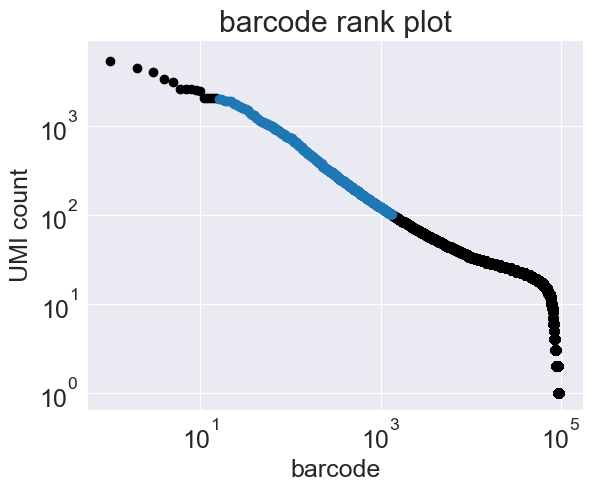

C:\Users\owner\Documents\Projects\rnaseq_correlations\src\data_functions.py:60: RuntimeWarning: invalid value encountered in divide
  dispersion = var / mean


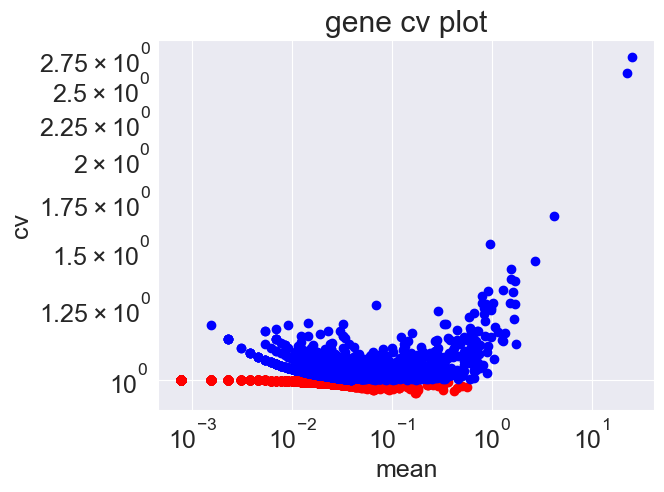

1839
1308


In [434]:
amat.reset_filters()
# filter by umi count
#filter by kanR:
#index = np.where(amat.var_names=='kanr')[0][0]
#amat.filtered_obj[amat.m[:,index]<=1] = False
#
df.AnnMat.filter_by_umi_count(amat, 100,2000)
# filter by gene dispersion
df.AnnMat.filter_by_gene_dispersion(amat, min_dispersion=1)


#amat = df.AnnMat.get_filtered_matrix(amat)
print(np.sum(amat.filtered_var))
print(np.sum(amat.filtered_obj))

In [3]:
# get annotated matrix from file
dir = os.path.join(os.path.dirname(os.getcwd()), 'filtered_data')
file_name = 'VapC_biorep_t5A_filtered.csv'
path = os.path.join(dir, file_name)
# read from csv
amat = df.read_from_csv(path)

<Axes: xlabel='$\\lambda$', ylabel='$\\rho(\\lambda)$'>

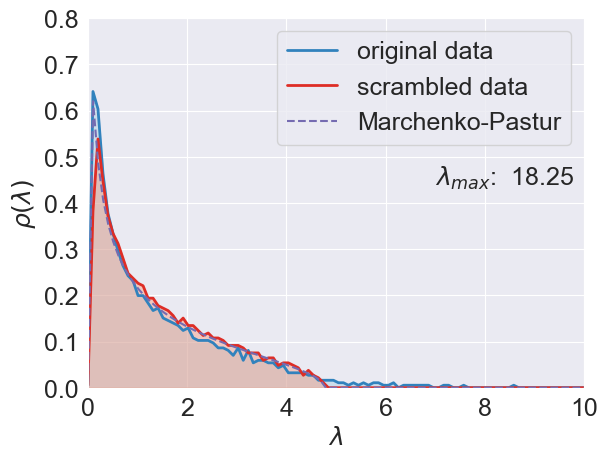

In [437]:
# remove tracker genes from the matrix
t_genes=[]
#amat.reset_filters()
index = [np.where(amat.var_names==val)[0][0] for val in t_genes if val in amat.var_names]
# filter the genes
amat.filtered_var[np.array(index).astype(int)] = False
m = amat.get_filtered_matrix().m
# get pcs
pcs, pcs1 = af.get_eig_dist(m, norm=True, log=False, norm_method='sum', norm_sum=50)

df.plot_eig_dist(pcs,pcs1, m.shape[0], 10, 0.8, 101)

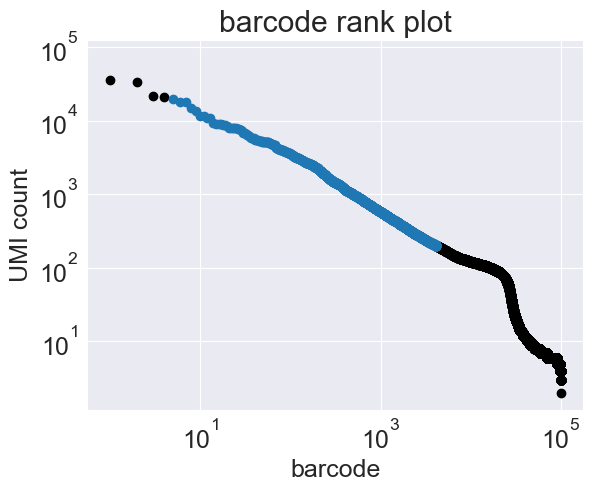

C:\Users\owner\Documents\Projects\rnaseq_correlations\src\data_functions.py:67: RuntimeWarning: invalid value encountered in divide
  dispersion = var / mean


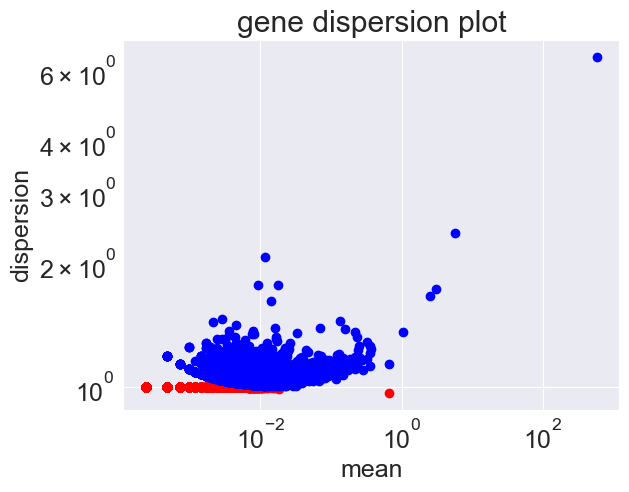

In [4]:
# plot UMAP embedding of the matrix
# get annotated matrix from file
dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
file_name = 'sample_13a_unfiltered.csv'
path = os.path.join(dir, file_name)
# read from csv
amat = df.read_from_csv(path)
# filter by umi count
df.AnnMat.filter_by_umi_count(amat, 200,20000)
# filter by gene dispersion
df.AnnMat.filter_by_gene_dispersion(amat)
# get filtered matrix
amat = df.AnnMat.get_filtered_matrix(amat)
# get umap embedding
embedding = df.get_umap(amat)

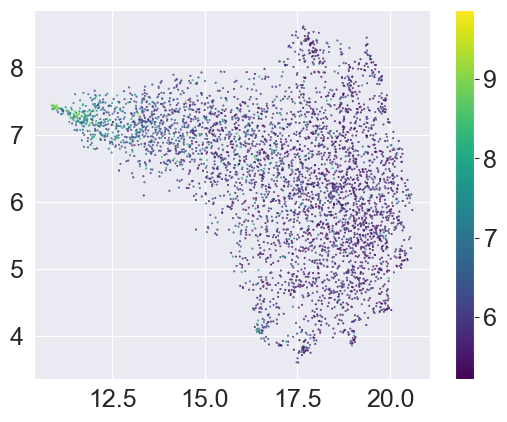

In [5]:
# get vector of umi count per cell
umi_count = np.sum(amat.m, axis=1)
# plot UMAP embedding
plt.scatter(embedding[:, 0], embedding[:, 1],c=np.log(umi_count), s=0.2, cmap='viridis')
plt.colorbar()
plt.show()